# Objetivo do Notebook

Este notebook tem como objetivo:

- Carregar e explorar conjuntos de dados reais: Iris e Diamonds.
- Aplicar conceitos de análise estatística descritiva.
- Explorar técnicas de normalização de dados:
-- Padronização (Z-score)
-- Normalização Min-Max
-- Branqueamento (Whitening)
- Praticar a análise e visualização de dados.
- Estimular a experimentação com atividades complementares.




## **1. Importação das bibliotecas**

In [1]:
# Manipulação de dados
import numpy as np
import pandas as pd

# Visualização
import seaborn as sns
import matplotlib.pyplot as plt

# Pré-processamento
from scipy.cluster.vq import whiten

## **2. Dataset Iris**



O *dataset* Iris é um dos mais famosos da área de ciência de dados e aprendizado de máquina. Ele contém informações sobre 150 flores, divididas em 3 espécies diferentes: *Iris setosa*, *Iris versicolor* e *Iris virginica*.

Para cada flor, temos 4 características:

- Comprimento da sépala  
- Largura da sépala  
- Comprimento da pétala  
- Largura da pétala  

Essas medidas foram coletadas para ajudar a diferenciar as espécies. Por isso, esse conjunto é muito usado em exemplos de classificação e em estudos de análise estatística.  

In [24]:
# Utilize o seaborn para carregar o dataset 'iris'
df_iris = sns.load_dataset('iris')

# Visualize os primeiros registros
df_iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## **3. Dataset Diamonds**

O *dataset* Diamonds contém informações sobre preços e características físicas de mais de 50 mil diamantes.  Ele é muito usado em projetos de ciência de dados para explorar variáveis numéricas e categóricas, além de aplicar técnicas de regressão.

Cada linha representa um diamante, e entre as colunas mais importantes, temos:

- `price`: preço do diamante (em dólares)
- `carat`: peso do diamante
- `cut`: qualidade do corte (Fair, Good, Very Good, Premium, Ideal)
- `color`: qualidade da cor (de J - pior, até D - melhor)
- `clarity`: pureza (de I1 - pior, até IF - melhor)
- `x`, `y`, `z`: dimensões físicas do diamante (em mm)

Esse conjunto é excelente para aprender a analisar relações entre variáveis, fazer visualizações gráficas e treinar modelos de regressão para prever o preço dos diamantes com base em suas características.


In [3]:
# Utilize o seaborn para carregar o dataset 'diamonds'

diamonds = sns.load_dataset('diamonds')
# Visualize os primeiros registros
print(diamonds.head())

   carat      cut color clarity  depth  table  price     x     y     z
0   0.23    Ideal     E     SI2   61.5   55.0    326  3.95  3.98  2.43
1   0.21  Premium     E     SI1   59.8   61.0    326  3.89  3.84  2.31
2   0.23     Good     E     VS1   56.9   65.0    327  4.05  4.07  2.31
3   0.29  Premium     I     VS2   62.4   58.0    334  4.20  4.23  2.63
4   0.31     Good     J     SI2   63.3   58.0    335  4.34  4.35  2.75


## **4. Estatísticas Descritivas - Dataset Iris**



In [30]:
df_iris.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


### **4.1 Média**

In [29]:
# Calcule a média de cada coluna numérica
print(df_iris_numeric.mean())
# Calcule a média de cada coluna numérica

sepal_length    5.843333
sepal_width     3.057333
petal_length    3.758000
petal_width     1.199333
dtype: float64


### **4.2 Desvio Padrão**

In [28]:
# Criar um subdataset somente com as colunas numéricas
df_iris_numeric = df_iris.select_dtypes(include=[np.number])
print(df_iris_numeric.std())
# Calcule o desvio padrão de cada coluna numérica

sepal_length    0.828066
sepal_width     0.435866
petal_length    1.765298
petal_width     0.762238
dtype: float64


### **4.3 Moda**

In [31]:
# Calcule a moda de cada coluna numérica
df_iris_numeric.mode()

,sepal_length,sepal_width,petal_length,petal_width
0,5.0,3.0,1.4,0.2
1,NaN,NaN,1.5,NaN


### **4.4 Mediana**

In [32]:
# Calcule a mediana de cada coluna numérica
df_iris_numeric.median()

sepal_length    5.80
sepal_width     3.00
petal_length    4.35
petal_width     1.30
dtype: float64

### **4.5 Quartis**

In [33]:
# Calcule o primeiro quartil (25%)
df_iris_numeric.quantile(0.25)

sepal_length    5.1
sepal_width     2.8
petal_length    1.6
petal_width     0.3
Name: 0.25, dtype: float64

### **4.6 Estatísticas Descritivas - Dataset diamonds**



In [35]:
# Aplique as mesmas estatísticas acima no dataset diamonds
# Dica: use numeric_only=True
df_diamonds = diamonds.select_dtypes(include=[np.number])
# Exemplo: df_diamonds.mean(numeric_only=True)
print(df_diamonds.mean(numeric_only=True))

carat       0.797940
depth      61.749405
table      57.457184
price    3932.799722
x           5.731157
y           5.734526
z           3.538734
dtype: float64


## **5. Covariância e Correlação - Dataset Iris**

In [36]:
# Calcule a matriz de covariância das variáveis numéricas
df_iris_numeric.cov()

,sepal_length,sepal_width,petal_length,petal_width
sepal_length,0.685694,-0.042434,1.274315,0.516271
sepal_width,-0.042434,0.189979,-0.329656,-0.121639
petal_length,1.274315,-0.329656,3.116278,1.295609
petal_width,0.516271,-0.121639,1.295609,0.581006


In [37]:
# Calcule a matriz de correlação (coeficiente de Pearson)
df_iris_numeric.corr()

,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.000000,-0.117570,0.871754,0.817941
sepal_width,-0.117570,1.000000,-0.428440,-0.366126
petal_length,0.871754,-0.428440,1.000000,0.962865
petal_width,0.817941,-0.366126,0.962865,1.000000


## **6. Normalizações - Dataset Iris**

### **6.1 Padronização (Z-score)**

In [41]:
df_iris_numeric.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [40]:
df_iris_numeric.head()  

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [39]:
# Padronize os dados: (x - média) / desvio padrão
df_iris_standardized = (df_iris_numeric - df_iris_numeric.mean()) / df_iris_numeric.std()
# Visualize os dados padronizados
df_iris_standardized.head()

,sepal_length,sepal_width,petal_length,petal_width
0,-0.897674,1.015602,-1.335752,-1.311052
1,-1.139200,-0.131539,-1.335752,-1.311052
2,-1.380727,0.327318,-1.392399,-1.311052
3,-1.501490,0.097889,-1.279104,-1.311052
4,-1.018437,1.245030,-1.335752,-1.311052


In [42]:
# Verifique a covariância após a padronização
df_iris_standardized.cov()

,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.000000,-0.117570,0.871754,0.817941
sepal_width,-0.117570,1.000000,-0.428440,-0.366126
petal_length,0.871754,-0.428440,1.000000,0.962865
petal_width,0.817941,-0.366126,0.962865,1.000000


### **6.2 Normalização Min-Max**

In [44]:
# Normalize os dados para o intervalo [0, 1]
df_iris_numeric_min = df_iris_numeric.min()
df_iris_numeric_max = df_iris_numeric.max() 
# Visualize os dados normalizados
df_iris_normalized = (df_iris_numeric - df_iris_numeric_min) / (df_iris_numeric_max - df_iris_numeric_min)
df_iris_normalized.head()


,sepal_length,sepal_width,petal_length,petal_width
0,0.222222,0.625000,0.067797,0.041667
1,0.166667,0.416667,0.067797,0.041667
2,0.111111,0.500000,0.050847,0.041667
3,0.083333,0.458333,0.084746,0.041667
4,0.194444,0.666667,0.067797,0.041667


In [45]:
# Verifique a covariância após a normalização
df_iris_normalized.cov()


,sepal_length,sepal_width,petal_length,petal_width
sepal_length,0.052908,-0.004911,0.059996,0.059754
sepal_width,-0.004911,0.032983,-0.023281,-0.021118
petal_length,0.059996,-0.023281,0.089522,0.091498
petal_width,0.059754,-0.021118,0.091498,0.100869


### **6.3 Branqueamento (Whitening)**
Branqueamento é um processo que remove correlações entre variáveis e padroniza a variância de cada uma delas. Depois do branqueamento:

- Todas as variáveis têm média zero
- Todas têm variância igual a 1
- As variáveis ficam descorrelacionadas (isto é, a matriz de covariância vira a identidade)

Por que fazer isso?
- Para evitar que variáveis altamente correlacionadas dominem o modelo
- Para melhorar o desempenho de algoritmos de aprendizado, especialmente os que assumem independência entre atributos (como PCA, ICA, redes neurais em alguns casos)
- Para acelerar o convergência de algoritmos de otimização (como no treinamento de redes neurais)

In [50]:
# Selecione as colunas numéricas
df_diamonds.head()
# Aplique o branqueamento com whiten()
df_diamonds_whitened = whiten(df_diamonds.select_dtypes(include=[np.number]))    

# Converta de volta para DataFrame
df_diamonds_whitened = pd.DataFrame(df_diamonds_whitened, columns=df_diamonds.select_dtypes(include=[np.number]).columns)

# Visualize o resultado
df_diamonds_whitened.head()


,carat,depth,table,price,x,y,z
0,0.485225,42.928699,24.614340,0.081716,3.521283,3.484735,3.443427
1,0.443032,41.742053,27.299540,0.081716,3.467795,3.362157,3.273381
2,0.485225,39.717772,29.089674,0.081967,3.610429,3.563536,3.273381
3,0.611806,43.556924,25.956940,0.083722,3.744149,3.703626,3.726837
4,0.653999,44.185149,25.956940,0.083972,3.868954,3.808693,3.896883


In [52]:
df_diamonds.cov()

,carat,depth,table,price,x,y,z
carat,0.224687,0.019167,0.192365,1.742765e+03,0.518484,0.515248,0.318917
depth,0.019167,2.052404,-0.946840,-6.085371e+01,-0.040641,-0.048009,0.095968
table,0.192365,-0.946840,4.992948,1.133318e+03,0.489643,0.468972,0.237996
price,1742.765364,-60.853712,1133.318064,1.591563e+07,3958.021491,3943.270810,2424.712613
x,0.518484,-0.040641,0.489643,3.958021e+03,1.258347,1.248789,0.768487
y,0.515248,-0.048009,0.468972,3.943271e+03,1.248789,1.304472,0.767320
z,0.318917,0.095968,0.237996,2.424713e+03,0.768487,0.767320,0.498011


In [51]:
# Verifique a covariância após o branqueamento
df_diamonds_whitened.cov()

,carat,depth,table,price,x,y,z
carat,1.000019,0.028225,0.181621,0.921608,0.975112,0.951740,0.953405
depth,0.028225,1.000019,-0.295784,-0.010648,-0.025290,-0.029341,0.094926
table,0.181621,-0.295784,1.000019,0.127136,0.195348,0.183764,0.150931
price,0.921608,-0.010648,0.127136,1.000019,0.884452,0.865437,0.861265
x,0.975112,-0.025290,0.195348,0.884452,1.000019,0.974720,0.970790
y,0.951740,-0.029341,0.183764,0.865437,0.974720,1.000019,0.952023
z,0.953405,0.094926,0.150931,0.861265,0.970790,0.952023,1.000019


### **6.4 Normalizações - Dataset diamons**

In [55]:
# Aplique as 3 técnicas de normalização no dataset diamonds
# padronizar o dataset diamonds com z-score 
df_diamonds_standardized = (df_diamonds - df_diamonds.mean()) / df_diamonds.std()  
df_diamonds_standardized.head() 
# normalizar o dataset diamonds para o intervalo [0, 1]
df_diamonds_min = df_diamonds.min() 
df_diamonds_max = df_diamonds.max() 
df_diamonds_normalized = (df_diamonds - df_diamonds_min) / (df_diamonds_max - df_diamonds_min)
# branqueamento do dataset diamonds
df_diamonds_whitened = whiten(df_diamonds.select_dtypes(include=[np.number]))

# Lembre-se de trabalhar apenas com colunas numéricas
# Dica: use df_diamonds.select_dtypes(include=np.number)

# Exemplo: diamonds_numeric = df_diamonds.select_dtypes(include=np.number)

## **7. Visualizações**

### **7.1 Histograma da variável original**

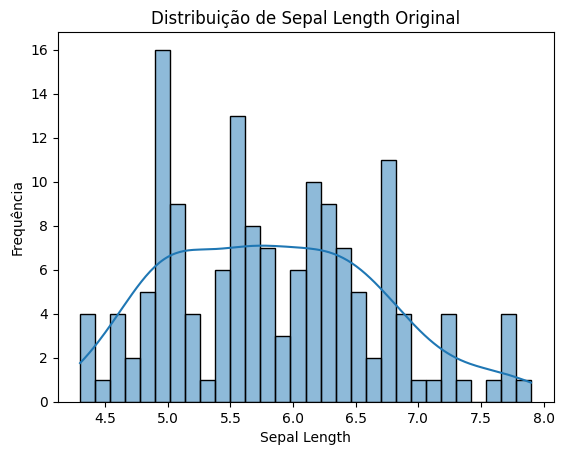

In [57]:
# Plote a distribuição de sepal_length original
sns.histplot(df_iris['sepal_length'], kde=True, bins=30)
plt.title('Distribuição de Sepal Length Original')
plt.xlabel('Sepal Length')
plt.ylabel('Frequência')
plt.show()



### **7.2 Histograma da variável padronizada**

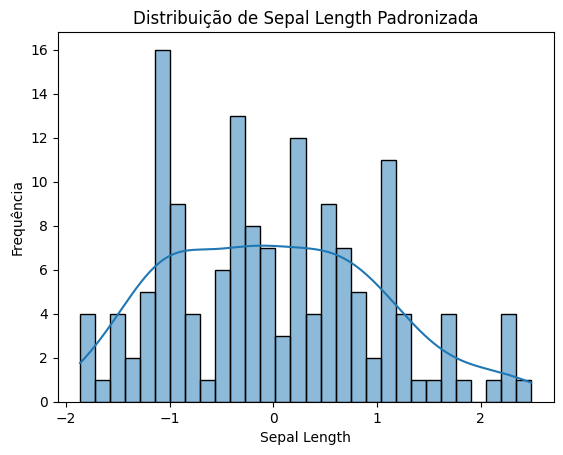

In [58]:
# Plote a distribuição após padronização
sns.histplot(df_iris_standardized['sepal_length'], kde=True, bins=30)
plt.title('Distribuição de Sepal Length Padronizada')   
plt.xlabel('Sepal Length')
plt.ylabel('Frequência')
plt.show()


### **7.3 Histograma das variáveis restantes**

In [ ]:
# Crie os mesmos gráficos comparativos para:
# - sepal_width
# - petal_length
# - petal_width

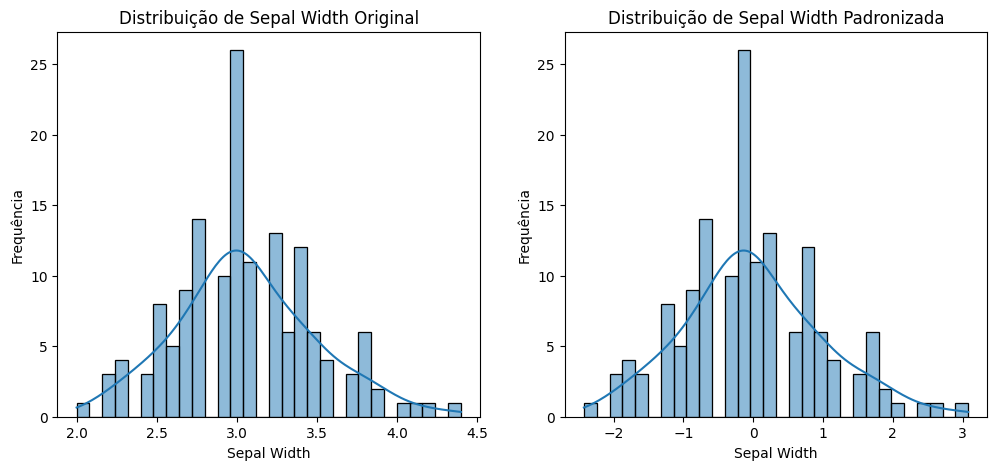

In [60]:
# Plote a distribuição de sepal_width original e após a padronização com 2 gráficos
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df_iris['sepal_width'], kde=True, bins=30)
plt.title('Distribuição de Sepal Width Original')
plt.xlabel('Sepal Width')
plt.ylabel('Frequência')
plt.subplot(1, 2, 2)
sns.histplot(df_iris_standardized['sepal_width'], kde=True, bins=30)
plt.title('Distribuição de Sepal Width Padronizada')
plt.xlabel('Sepal Width')
plt.ylabel('Frequência')
plt.show()




## **8. Desafio**

In [66]:
import sklearn

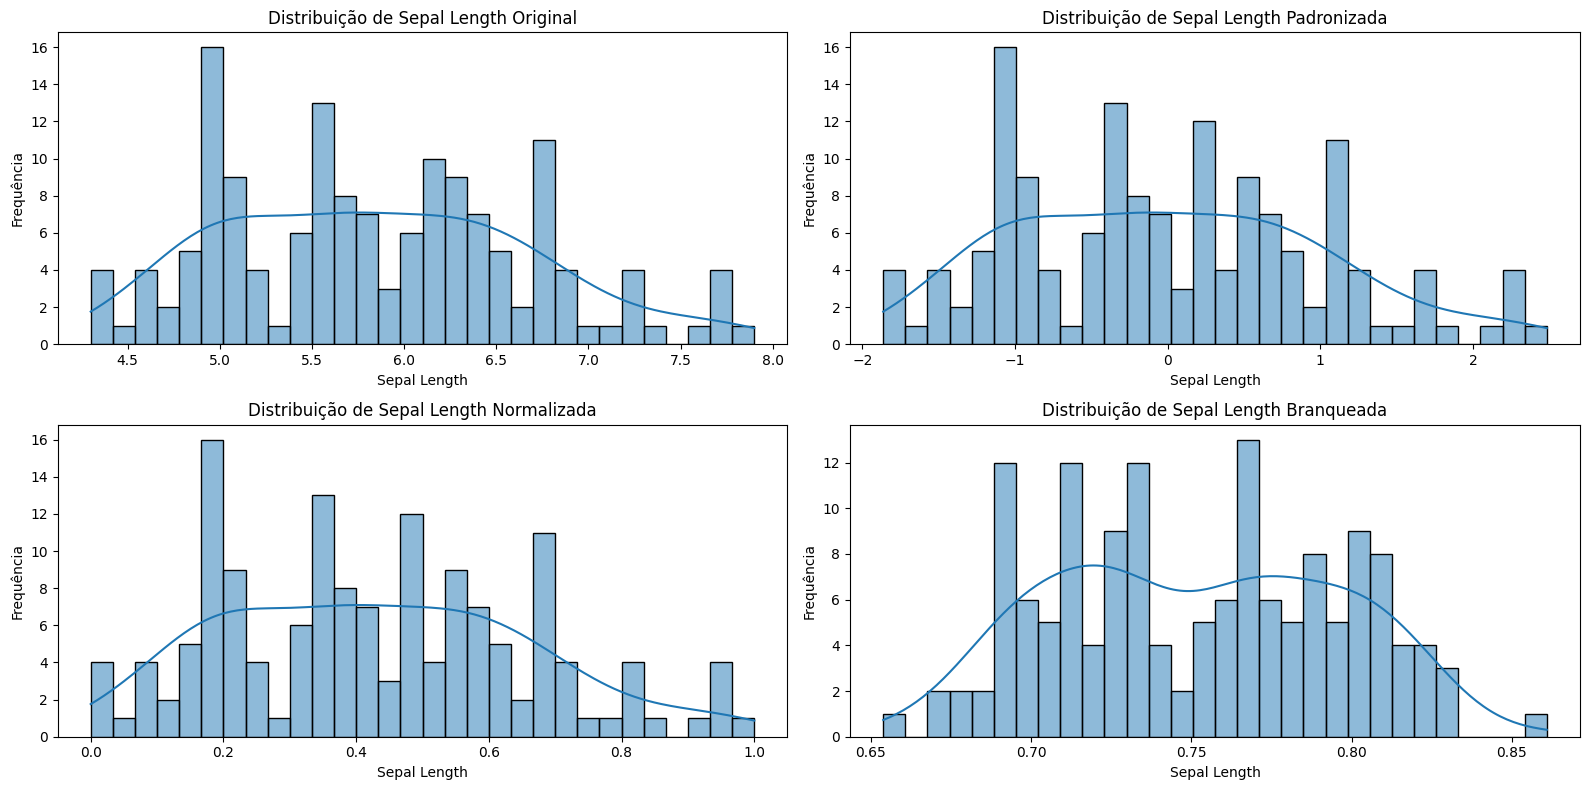

In [68]:
# Experimente usar normalizações da biblioteca sklearn:
# from sklearn.preprocessing import StandardScaler, MinMaxScaler, Normalizer
# Padronização com StandardScaler
from sklearn.preprocessing import StandardScaler, MinMaxScaler, Normalizer
scaler = StandardScaler()
df_iris_standardized_sklearn = scaler.fit_transform(df_iris_numeric)
df_iris_standardized_sklearn = pd.DataFrame(df_iris_standardized_sklearn, columns=df_iris_numeric.columns)
# Normalização com MinMaxScaler
scaler = MinMaxScaler()
df_iris_normalized_sklearn = scaler.fit_transform(df_iris_numeric)
df_iris_normalized_sklearn = pd.DataFrame(df_iris_normalized_sklearn, columns=df_iris_numeric.columns)
# Branqueamento com Normalizer
scaler = Normalizer()
df_iris_whitened_sklearn = scaler.fit_transform(df_iris_numeric)
df_iris_whitened_sklearn = pd.DataFrame(df_iris_whitened_sklearn, columns=df_iris_numeric.columns)


# Tente comparar visualmente os resultados com seaborn ou matplotlib
# Plote a distribuição de sepal_length original e após a padronização com 4 gráficos, original, padronizado, normalizado e branqueado
plt.figure(figsize=(16, 8))
plt.subplot(2, 2, 1)
sns.histplot(df_iris['sepal_length'], kde=True, bins=30)
plt.title('Distribuição de Sepal Length Original')
plt.xlabel('Sepal Length')
plt.ylabel('Frequência')
plt.subplot(2, 2, 2)
sns.histplot(df_iris_standardized['sepal_length'], kde=True, bins=30)
plt.title('Distribuição de Sepal Length Padronizada')
plt.xlabel('Sepal Length')
plt.ylabel('Frequência')
plt.subplot(2, 2, 3)
sns.histplot(df_iris_normalized['sepal_length'], kde=True, bins=30)
plt.title('Distribuição de Sepal Length Normalizada')
plt.xlabel('Sepal Length')
plt.ylabel('Frequência')
plt.subplot(2, 2, 4)
sns.histplot(df_iris_whitened_sklearn['sepal_length'], kde=True, bins=30)
plt.title('Distribuição de Sepal Length Branqueada')
plt.xlabel('Sepal Length')
plt.ylabel('Frequência')
plt.tight_layout()
plt.show()
